# Exploratory Data Analysis: Substation Power Monitoring & Fault Classification Dataset

**File:** `train.csv` &nbsp;|&nbsp; **Rows:** 330,000 &nbsp;|&nbsp; **Columns:** 20 &nbsp;|&nbsp; **Size:** ~48 MB

This notebook performs a complete, from-scratch exploratory data analysis of an electrical
substation monitoring dataset. The data records electrical measurements (voltage, current,
power, frequency, power factor, loading) sampled over time across **11 substations**, organized
into **200 simulated episodes** of **150 timesteps** each. Some episodes contain **fault/anomaly
events** (voltage sags, frequency deviations, line/ground faults, overloads, trips), making this
a candidate dataset for **fault detection / event classification** modeling.

The notebook is written to be **adaptable**: column groups (numeric / categorical / id columns)
are detected programmatically wherever possible, and helper functions are reused across sections
rather than hard-coded per-column, so most cells will keep working if columns are added, removed,
or renamed.

**Contents**
1. Setup & Data Loading
2. First Look (shape, dtypes, sample rows)
3. Data Dictionary (inferred column meanings)
4. Dataset Structure Discovery (episodes × substations × time)
5. Missing Data Analysis
6. Duplicate Rows
7. Target Variable Analysis
8. Numeric Feature Distributions
9. Outlier Analysis
10. Categorical Feature Distributions
11. Correlation Analysis
12. Bivariate Analysis: Numeric Features vs Target
13. Bivariate Analysis: Categorical Features vs Target
14. Time-Series / Episode-Level View
15. Substation-Level Analysis
16. Domain / Physics Sanity Checks
17. Key Findings & Modeling Recommendations


## 1. Setup & Data Loading

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

DATA_PATH = "train.csv"
df = pd.read_csv(DATA_PATH)
df.shape


(330000, 20)

In [2]:

# Basic column-type detection (kept adaptable so later cells auto-adjust
# if the schema changes). We refine these lists slightly in Section 3.
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


Numeric columns (11): ['time_s', 'episode_id', 'V_hv_kV', 'V_lv_kV', 'I_hv_A', 'P_MW', 'Q_Mvar', 'S_MVA', 'PF', 'loading_pct', 'freq_Hz']
Categorical columns (9): ['substation', 'equip_status', 'breaker_status', 'relay_status', 'label', 'fault_location', 'event_label', 'local_label', 'lifecycle_stage']


## 2. First Look

In [3]:

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(10)


Shape: 330,000 rows x 20 columns


Memory usage: 199.1 MB


,time_s,substation,episode_id,V_hv_kV,V_lv_kV,I_hv_A,P_MW,Q_Mvar,S_MVA,PF,loading_pct,freq_Hz,equip_status,breaker_status,relay_status,label,fault_location,event_label,local_label,lifecycle_stage
0,0,Laverie/Sechage SN1,0,45.895,4.037,84.64,5.785,2.887,6.465,0.895,69.21,50.015,HEALTHY,CLOSED,ALARM,voltage_sag,Laverie/Sechage SN2,voltage_sag,voltage_sag,NaN
1,0,Laverie/Sechage SN2,0,46.497,4.144,81.24,5.643,2.784,6.292,0.897,67.28,50.014,HEALTHY,CLOSED,ALARM,voltage_sag,Laverie/Sechage SN2,voltage_sag,voltage_sag,NaN
2,0,Mine Mzinda DIS TR,0,46.417,4.121,33.61,2.395,1.096,2.634,0.909,46.83,49.987,HEALTHY,CLOSED,ALARM,voltage_sag,Laverie/Sechage SN2,voltage_sag,voltage_sag,NaN
3,0,PSF Mine Bouchane SN6,0,46.248,4.085,14.72,1.046,0.528,1.172,0.893,62.08,49.995,HEALTHY,CLOSED,ALARM,voltage_sag,Laverie/Sechage SN2,voltage_sag,voltage_sag,NaN
4,0,Recette 3 SN3,0,45.291,4.021,12.91,0.898,0.465,1.011,0.888,67.83,50.005,HEALTHY,CLOSED,ALARM,voltage_sag,Laverie/Sechage SN2,voltage_sag,voltage_sag,NaN
5,0,Recette 9 SN9,0,45.240,4.019,15.53,1.089,0.549,1.220,0.893,65.11,50.015,HEALTHY,CLOSED,ALARM,voltage_sag,Laverie/Sechage SN2,voltage_sag,voltage_sag,NaN
6,0,U Calcination SN1,0,44.867,4.023,42.12,2.969,1.376,3.272,0.907,34.94,49.993,HEALTHY,CLOSED,ALARM,voltage_sag,Laverie/Sechage SN2,voltage_sag,voltage_sag,NaN
7,0,U Calcination SN2,0,46.251,4.168,45.22,3.109,1.554,3.476,0.894,37.48,49.997,HEALTHY,CLOSED,ALARM,voltage_sag,Laverie/Sechage SN2,voltage_sag,voltage_sag,NaN
8,0,U Calcination SN3,0,45.934,4.134,36.12,2.597,1.169,2.848,0.912,38.01,49.983,HEALTHY,CLOSED,ALARM,voltage_sag,Laverie/Sechage SN2,voltage_sag,voltage_sag,NaN
9,0,SSP Local ST1,0,46.260,4.181,24.55,1.704,0.835,1.898,0.898,50.85,49.982,HEALTHY,CLOSED,ALARM,voltage_sag,Laverie/Sechage SN2,voltage_sag,voltage_sag,NaN


In [4]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 330000 entries, 0 to 329999
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   time_s           330000 non-null  int64  
 1   substation       330000 non-null  str    
 2   episode_id       330000 non-null  int64  
 3   V_hv_kV          329657 non-null  float64
 4   V_lv_kV          329657 non-null  float64
 5   I_hv_A           329657 non-null  float64
 6   P_MW             329657 non-null  float64
 7   Q_Mvar           329657 non-null  float64
 8   S_MVA            329657 non-null  float64
 9   PF               329657 non-null  float64
 10  loading_pct      329657 non-null  float64
 11  freq_Hz          330000 non-null  float64
 12  equip_status     330000 non-null  str    
 13  breaker_status   330000 non-null  str    
 14  relay_status     330000 non-null  str    
 15  label            330000 non-null  str    
 16  fault_location   330000 non-null  str    
 17  ev

In [5]:

# Full numeric summary (all percentiles-of-interest)
df.describe(include=np.number).T


,count,mean,std,min,25%,50%,75%,max
time_s,330000.0,74.500000,43.300374,0.000,37.000,74.500,112.000,149.000
episode_id,330000.0,99.500000,57.734393,0.000,49.750,99.500,149.250,199.000
V_hv_kV,329657.0,54.257740,13.334294,0.000,56.044,59.272,60.179,61.857
V_lv_kV,329657.0,4.899460,1.212866,0.000,5.069,5.353,5.435,6.578
I_hv_A,329657.0,54.845911,129.662203,0.000,15.440,30.230,62.770,5777.230
P_MW,329657.0,2.912002,2.187387,0.000,1.280,2.672,4.380,92.019
Q_Mvar,329657.0,1.768889,5.993857,0.000,0.657,1.251,2.679,288.300
S_MVA,329657.0,3.489588,6.335803,0.000,1.456,2.979,5.303,290.294
PF,329657.0,0.846072,0.177769,0.000,0.843,0.889,0.913,0.994
loading_pct,329657.0,76.233142,121.267475,0.000,30.420,44.710,57.200,2500.000


In [6]:

# Full categorical / object summary
df.describe(include="object").T


,count,unique,top,freq
substation,330000,11,Laverie/Sechage SN1,30000
equip_status,330000,5,HEALTHY,308256
breaker_status,330000,4,CLOSED,313446
relay_status,330000,11,NORMAL,174300
label,330000,9,normal,255000
fault_location,330000,10,NONE,151800
event_label,330000,9,normal,151800
local_label,330000,9,normal,255000
lifecycle_stage,309541,7,normal,255991


## 3. Data Dictionary (Inferred)

Based on the column names, value ranges, and the structural analysis in Section 4, the
columns appear to represent the following (electrical substation SCADA-style telemetry):

| Column | Type | Meaning |
|---|---|---|
| `time_s` | int | Timestep within an episode (0–149) |
| `substation` | categorical | Name of the monitored substation (11 unique) |
| `episode_id` | int | Simulation/episode identifier (200 unique) |
| `V_hv_kV` | float | Voltage on the high-voltage side (kV) |
| `V_lv_kV` | float | Voltage on the low-voltage side (kV) |
| `I_hv_A` | float | Current on the high-voltage side (A) |
| `P_MW` | float | Real (active) power (MW) |
| `Q_Mvar` | float | Reactive power (MVAr) |
| `S_MVA` | float | Apparent power (MVA) — derived, ≈ √(P² + Q²) |
| `PF` | float | Power factor |
| `loading_pct` | float | Equipment loading as a % of rated capacity |
| `freq_Hz` | float | Grid frequency (Hz), nominal 50 Hz |
| `equip_status` | categorical | Equipment health status (HEALTHY / DEGRADED / FAULTED / OFFLINE / OVERLOADED) |
| `breaker_status` | categorical | Circuit breaker state (CLOSED / OPEN / OPENING / TRIP_COMMAND) |
| `relay_status` | categorical | Protection relay status (NORMAL / ALARM / TRIPPED / PICKUP variants / etc.) |
| `label` | categorical (**target**) | **Local**, per-substation, per-timestep event label |
| `local_label` | categorical | Identical to `label` (verified in Section 7 — fully redundant) |
| `fault_location` | categorical | Substation where the episode's fault/event originates (`NONE` if episode is normal) |
| `event_label` | categorical | **Episode-level** ground-truth event type (constant across all rows of an episode) |
| `lifecycle_stage` | categorical | Local temporal stage of a fault's progression (normal → pre_fault → fault_detected → relay_operated → breaker_open → isolated → restored); missing for events where this isn't tracked |

We'll confirm/refine these interpretations empirically as we go.


## 4. Dataset Structure Discovery

This dataset is not a plain flat table of independent rows — it's a **panel / multivariate time
series**: each row is one (episode, substation, timestep) observation. Let's confirm the
structure before doing anything else, since it changes how we should think about "duplicates,"
"outliers," and train/validation splitting.


In [7]:

n_episodes = df["episode_id"].nunique()
n_substations = df["substation"].nunique()
n_timesteps = df["time_s"].nunique()

print(f"Unique episodes:    {n_episodes}")
print(f"Unique substations: {n_substations}")
print(f"Unique timesteps:   {n_timesteps} (range {df.time_s.min()}-{df.time_s.max()})")
print(f"episodes x substations x timesteps = {n_episodes * n_substations * n_timesteps:,}")
print(f"actual row count                   = {len(df):,}")

rows_per_episode = df.groupby("episode_id").size()
print("\nRows per episode -> is the panel perfectly balanced?",
      "YES" if rows_per_episode.nunique() == 1 else "NO",
      f"(every episode has {rows_per_episode.iloc[0]} rows)")


Unique episodes:    200
Unique substations: 11
Unique timesteps:   150 (range 0-149)
episodes x substations x timesteps = 330,000
actual row count                   = 330,000

Rows per episode -> is the panel perfectly balanced? YES (every episode has 1650 rows)


In [8]:

# Every (episode_id, substation) pair should trace out one clean time series of 150 steps
panel_check = df.groupby(["episode_id", "substation"])["time_s"].agg(["min", "max", "count", "nunique"])
print("All (episode, substation) series run 0->149 with no gaps/dupes:",
      (panel_check["min"].eq(0) & panel_check["max"].eq(149) &
       panel_check["count"].eq(150) & panel_check["nunique"].eq(150)).all())
panel_check.head()


All (episode, substation) series run 0->149 with no gaps/dupes: True


min  max  count  nunique
episode_id substation                                     
0          Laverie/Sechage SN1      0  149    150      150
           Laverie/Sechage SN2      0  149    150      150
           Mine Mzinda DIS TR       0  149    150      150
           PSF Mine Bouchane SN6    0  149    150      150
           Recette 3 SN3            0  149    150      150

**Finding:** The dataset is a **perfectly balanced panel**: 200 episodes × 11 substations × 150
timesteps = 330,000 rows exactly, with every (episode, substation) pair forming a clean, gap-free
150-step time series. This confirms it as a simulated power-system dataset (e.g. built with a
tool like pandapower), not raw noisy field SCADA data.


In [9]:

print("Substations:", df["substation"].unique().tolist())


Substations: ['Laverie/Sechage SN1', 'Laverie/Sechage SN2', 'Mine Mzinda DIS TR', 'PSF Mine Bouchane SN6', 'Recette 3 SN3', 'Recette 9 SN9', 'U Calcination SN1', 'U Calcination SN2', 'U Calcination SN3', 'SSP Local ST1', 'SSP Local ST2']


## 5. Missing Data Analysis

We look at *how much* is missing, *which* columns are affected, and — importantly for this
dataset — *whether missingness is random or structurally tied to specific event types* (it
often is, in fault-simulation data, because some fields simply aren't tracked/applicable for
certain event types).


In [10]:

miss_count = df.isna().sum()
miss_pct = (miss_count / len(df) * 100).round(3)
missing_summary = (pd.DataFrame({"missing_count": miss_count, "missing_pct": miss_pct})
                    .query("missing_count > 0")
                    .sort_values("missing_pct", ascending=False))
missing_summary


,missing_count,missing_pct
lifecycle_stage,20459,6.200
V_hv_kV,343,0.104
V_lv_kV,343,0.104
P_MW,343,0.104
I_hv_A,343,0.104
Q_Mvar,343,0.104
S_MVA,343,0.104
PF,343,0.104
loading_pct,343,0.104


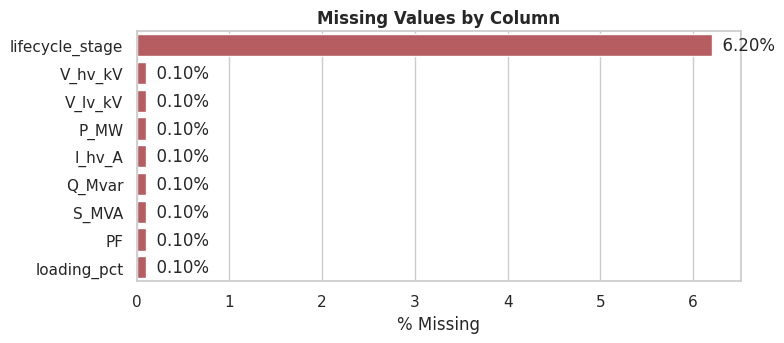

In [11]:

fig, ax = plt.subplots(figsize=(8, max(2, 0.4 * len(missing_summary))))
sns.barplot(x=missing_summary["missing_pct"], y=missing_summary.index, ax=ax, color="#c44e52")
ax.set_xlabel("% Missing")
ax.set_ylabel("")
ax.set_title("Missing Values by Column")
for i, v in enumerate(missing_summary["missing_pct"]):
    ax.text(v, i, f"  {v:.2f}%", va="center")
plt.tight_layout()
plt.show()


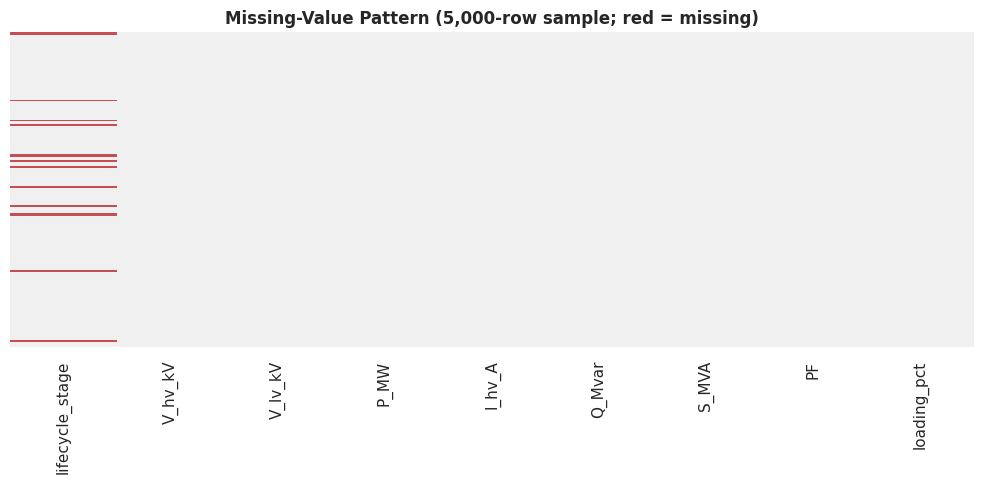

In [12]:

# Missingness heatmap (sampled for renderability) - reveals row-wise patterns
sample_idx = df.sample(min(5000, len(df)), random_state=42).sort_index().index
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.loc[sample_idx, missing_summary.index].isna(), cbar=False,
            yticklabels=False, cmap=["#f0f0f0", "#c44e52"], ax=ax)
ax.set_title("Missing-Value Pattern (5,000-row sample; red = missing)")
plt.tight_layout()
plt.show()


In [13]:

# Are the electrical-measurement gaps (V, I, P, Q, S, PF, loading_pct) random,
# or concentrated in specific equipment states?
sensor_cols = ["V_hv_kV", "V_lv_kV", "I_hv_A", "P_MW", "Q_Mvar", "S_MVA", "PF", "loading_pct"]
sensor_missing_mask = df[sensor_cols].isna().any(axis=1)
print(f"Rows with any sensor reading missing: {sensor_missing_mask.sum()} ({sensor_missing_mask.mean()*100:.2f}%)")
print("\nequip_status distribution when sensors are missing:")
print(df.loc[sensor_missing_mask, "equip_status"].value_counts())
print("\nequip_status distribution overall (for comparison):")
print(df["equip_status"].value_counts(normalize=True).round(3))


Rows with any sensor reading missing: 343 (0.10%)

equip_status distribution when sensors are missing:
equip_status
HEALTHY       326
OFFLINE        13
DEGRADED        3
OVERLOADED      1
Name: count, dtype: int64

equip_status distribution overall (for comparison):
equip_status
HEALTHY       0.934
OFFLINE       0.048
DEGRADED      0.013
FAULTED       0.002
OVERLOADED    0.002
Name: proportion, dtype: float64


In [14]:

# lifecycle_stage has by far the most missingness (6.2%) - check whether it's tied to a specific label
lifecycle_missing_by_label = (
    df.assign(lifecycle_missing=df["lifecycle_stage"].isna())
      .groupby("label")["lifecycle_missing"]
      .agg(["sum", "count"])
      .assign(pct_missing=lambda x: (x["sum"] / x["count"] * 100).round(1))
      .sort_values("pct_missing", ascending=False)
)
lifecycle_missing_by_label


,sum,count,pct_missing
label,,,
voltage_sag,20459,21450,95.4
breaker_trip,0,150,0.0
lg_fault,0,8850,0.0
normal,0,255000,0.0
ll_fault,0,7800,0.0
over_frequency,0,21450,0.0
overload,0,1800,0.0
transformer_trip,0,300,0.0
under_frequency,0,13200,0.0


**Findings:**
- The 8 electrical-measurement columns (`V_hv_kV` … `loading_pct`) are missing in exactly the
  same **343 rows (0.10%)** — a small, evenly-distributed sensor dropout, not concentrated in any
  one `equip_status`. Safe to impute (e.g. per-substation median/interpolation) or drop given how
  small this fraction is.
- `lifecycle_stage` is missing in **6.2%** of rows, and this is **almost entirely explained by
  `label == "voltage_sag"`** — for that event type the lifecycle stage simply isn't tracked in
  the simulation. This is a **structural NaN**, not random noise: it should probably be encoded
  as its own category (e.g. `"not_tracked"`) rather than imputed statistically.


## 6. Duplicate Rows

In [15]:

full_dupes = df.duplicated().sum()
key_dupes = df.duplicated(subset=["episode_id", "substation", "time_s"]).sum()
print(f"Fully duplicated rows: {full_dupes}")
print(f"Rows with duplicate (episode_id, substation, time_s) key: {key_dupes}")


Fully duplicated rows: 0
Rows with duplicate (episode_id, substation, time_s) key: 0


**Finding:** No duplicate rows at all, and the natural composite key `(episode_id, substation, time_s)` is unique for every row — the panel structure is clean.

## 7. Target Variable Analysis

This dataset actually carries **two related but different labels**, which is a key structural
insight:

- **`label` / `local_label`** — what a given substation *itself* is experiencing at that instant
  (verified below to be 100% identical columns).
- **`event_label`** — the *ground-truth event type for the whole episode*, constant across all
  200×150 rows of that episode, regardless of which substation is directly affected.

The difference matters because some event types are **network-wide** (a voltage sag or
frequency event shows up as the same `label` on *every* substation), while others are
**localized** (a line-to-ground fault shows `label = lg_fault` only at the originating
substation, `label = normal` everywhere else, while `event_label` stays `lg_fault` for the whole
episode). We treat **`label`** as the primary per-row target for a "what is this row showing"
classifier, and note `event_label` as the right target for an "episode-level" classifier.


In [16]:

print("label == local_label for every row:", (df["label"] == df["local_label"]).all())


label == local_label for every row: True


In [17]:

TARGET = "label"

label_counts = df[TARGET].value_counts()
label_pct = (label_counts / len(df) * 100).round(2)
target_summary = pd.DataFrame({"count": label_counts, "pct": label_pct})
target_summary


,count,pct
label,,
normal,255000,77.27
voltage_sag,21450,6.50
over_frequency,21450,6.50
under_frequency,13200,4.00
lg_fault,8850,2.68
ll_fault,7800,2.36
overload,1800,0.55
transformer_trip,300,0.09
breaker_trip,150,0.05


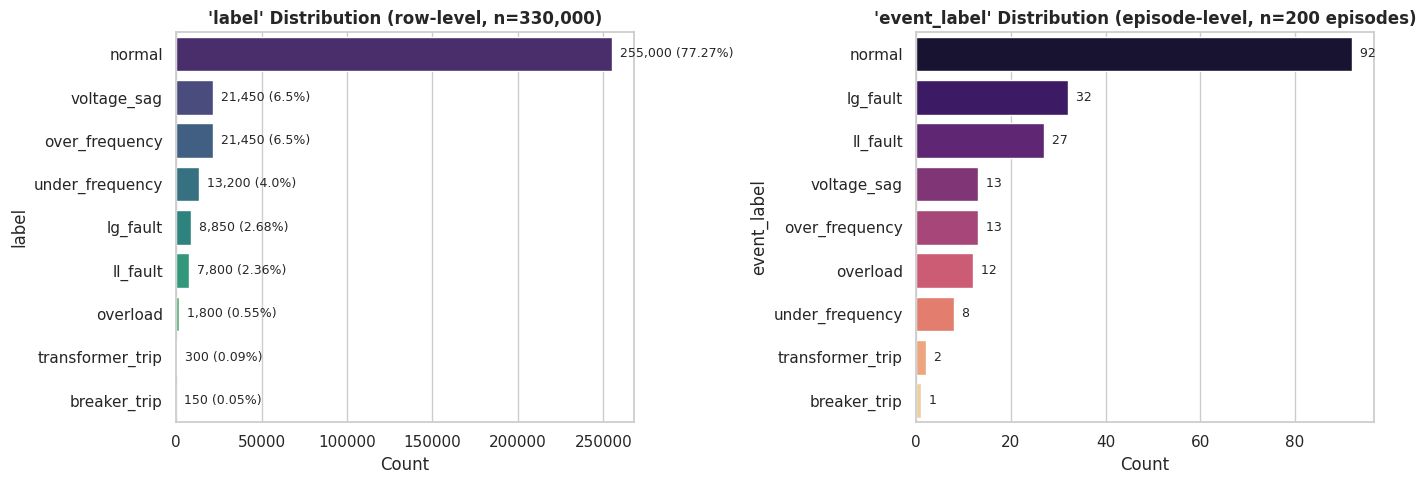

Class imbalance ratio (row-level, majority:minority) = 1700.0 : 1


In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = label_counts.index
sns.barplot(x=label_counts.values, y=order, ax=axes[0], palette="viridis")
axes[0].set_title(f"'{TARGET}' Distribution (row-level, n={len(df):,})")
axes[0].set_xlabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(v, i, f"  {v:,} ({label_pct.iloc[i]}%)", va="center", fontsize=9)

event_counts = df.groupby("episode_id")["event_label"].first().value_counts()
sns.barplot(x=event_counts.values, y=event_counts.index, ax=axes[1], palette="magma")
axes[1].set_title(f"'event_label' Distribution (episode-level, n={df.episode_id.nunique()} episodes)")
axes[1].set_xlabel("Count")
for i, v in enumerate(event_counts.values):
    axes[1].text(v, i, f"  {v}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Class imbalance ratio (row-level, majority:minority) = "
      f"{label_counts.max() / label_counts.min():.1f} : 1")


**Findings:**
- `label` is heavily imbalanced: **`normal` = 77.3%** of rows, versus the rarest classes
  (`breaker_trip` = 0.05%, `transformer_trip` = 0.09%) — a >1,700:1 ratio between the largest and
  smallest class. Any modeling on `label` will need class-imbalance handling (stratified
  sampling, class weights, focal loss, F1/AUPRC evaluation instead of accuracy, etc.).
- At the **episode** level (`event_label`), 92/200 (46%) episodes are entirely normal and the
  other 108 contain one specific fault type — a much better-balanced view of "how many distinct
  fault scenarios were simulated."


## 8. Numeric Feature Distributions

Excluding the ID/index-like columns (`time_s`, `episode_id`), we look at the distribution shape
of every electrical measurement: histogram, skewness, and kurtosis.


In [19]:

measurement_cols = [c for c in numeric_cols if c not in ("time_s", "episode_id")]

dist_stats = df[measurement_cols].agg(["mean", "std", "min", "median", "max"]).T
dist_stats["skew"] = df[measurement_cols].skew()
dist_stats["kurtosis"] = df[measurement_cols].kurtosis()
dist_stats.round(3)


,mean,std,min,median,max,skew,kurtosis
V_hv_kV,54.258,13.334,0.000,59.272,61.857,-3.131,9.333
V_lv_kV,4.899,1.213,0.000,5.353,6.578,-3.136,9.305
I_hv_A,54.846,129.662,0.000,30.230,5777.230,24.303,779.575
P_MW,2.912,2.187,0.000,2.672,92.019,8.946,238.647
Q_Mvar,1.769,5.994,0.000,1.251,288.300,33.238,1242.381
S_MVA,3.490,6.336,0.000,2.979,290.294,29.757,1070.610
PF,0.846,0.178,0.000,0.889,0.994,-4.189,16.948
loading_pct,76.233,121.267,0.000,44.710,2500.000,7.460,113.911
freq_Hz,50.005,0.218,48.486,50.000,51.201,-0.931,20.939


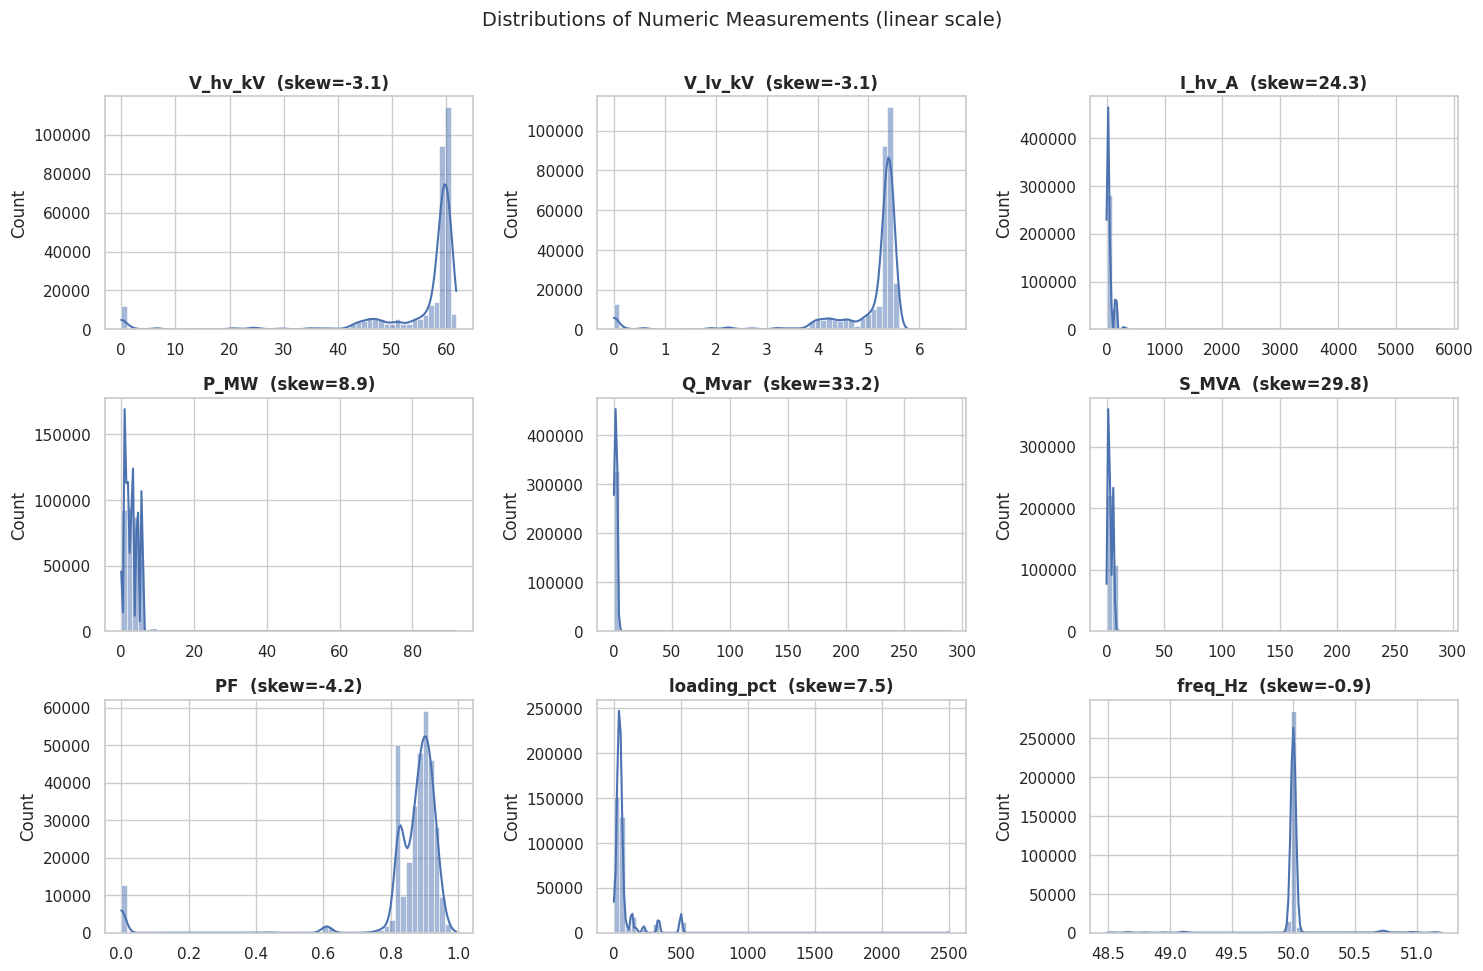

In [20]:

n = len(measurement_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = axes.flatten()

for i, col in enumerate(measurement_cols):
    sns.histplot(df[col].dropna(), bins=60, kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"{col}  (skew={df[col].skew():.1f})")
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distributions of Numeric Measurements (linear scale)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


Highly skewed columns (|skew| > 3): ['V_hv_kV', 'V_lv_kV', 'I_hv_A', 'P_MW', 'Q_Mvar', 'S_MVA', 'PF', 'loading_pct']


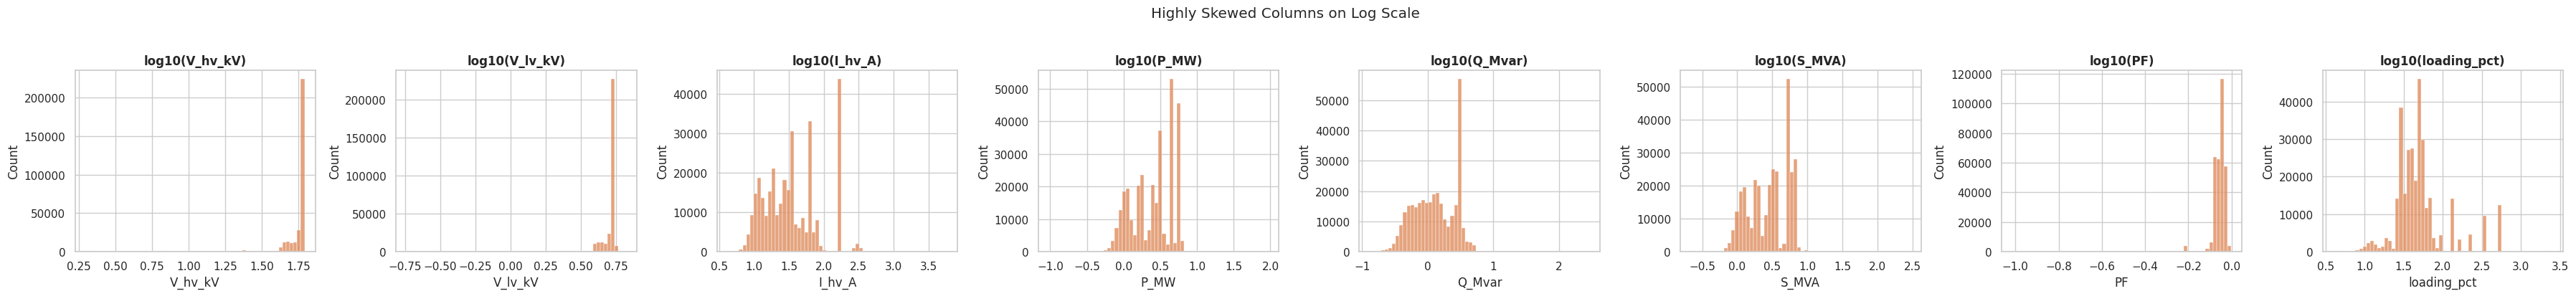

In [21]:

# Several columns (I_hv_A, Q_Mvar, S_MVA, loading_pct) are extremely right-skewed
# with long tails driven by fault events -> also view on log scale for the skewed ones
skewed_cols = dist_stats[dist_stats["skew"].abs() > 3].index.tolist()
print("Highly skewed columns (|skew| > 3):", skewed_cols)

fig, axes = plt.subplots(1, len(skewed_cols), figsize=(4.5 * len(skewed_cols), 4))
if len(skewed_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, skewed_cols):
    vals = df[col].dropna()
    vals = vals[vals > 0]
    sns.histplot(np.log10(vals), bins=60, ax=ax, color="#DD8452")
    ax.set_title(f"log10({col})")
plt.suptitle("Highly Skewed Columns on Log Scale", y=1.03)
plt.tight_layout()
plt.show()


**Finding:** `I_hv_A`, `Q_Mvar`, `S_MVA`, and `loading_pct` are strongly right-skewed
(skew ≈ 8–33) with a compact main mode plus a long tail of extreme values — the tail is
investigated in Section 9 and turns out to correspond to real fault events rather than data
errors. `V_hv_kV`, `V_lv_kV`, and `PF` are left-skewed (a ceiling near their normal operating
value, with a downward tail during sags/faults). `freq_Hz` is tightly centered on 50 Hz as
expected for grid frequency.


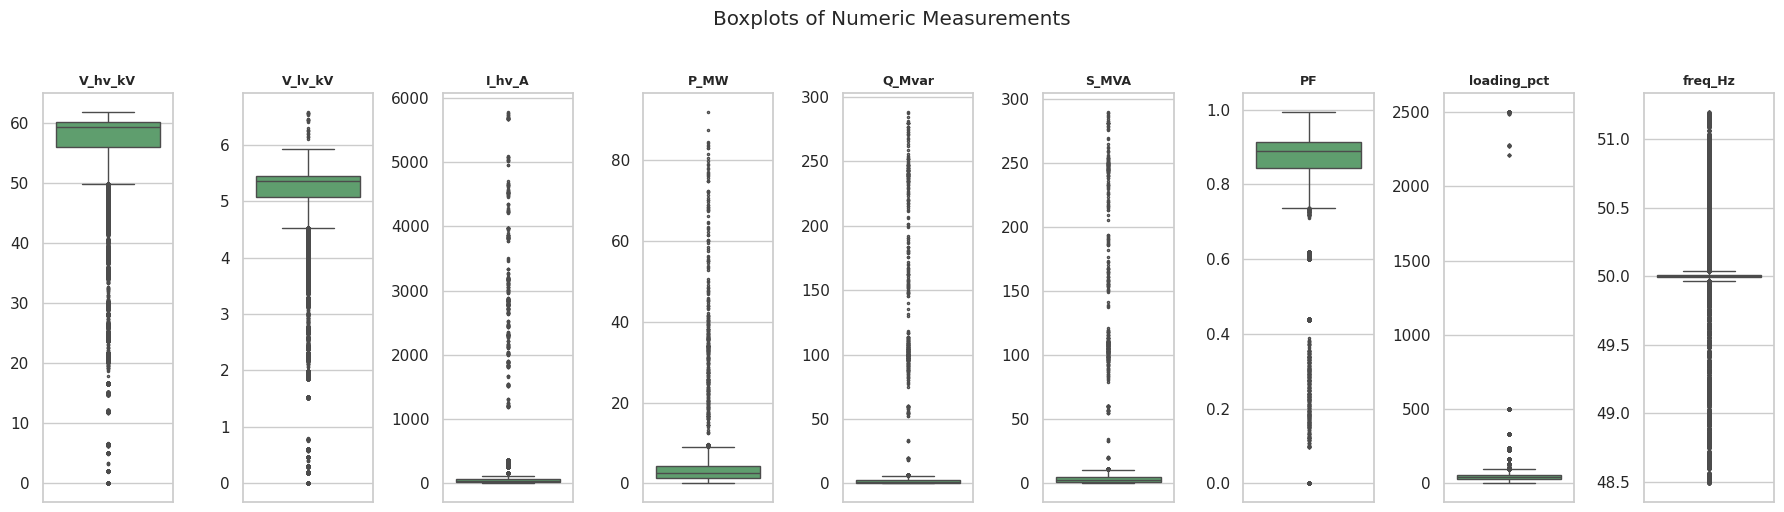

In [22]:

fig, axes = plt.subplots(1, len(measurement_cols), figsize=(2 * len(measurement_cols), 5))
for ax, col in zip(axes, measurement_cols):
    sns.boxplot(y=df[col], ax=ax, color="#55A868", fliersize=1.5)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
plt.suptitle("Boxplots of Numeric Measurements", y=1.02)
plt.tight_layout()
plt.show()


## 9. Outlier Analysis

Rather than assuming outliers are data-quality problems, we check **what they actually
represent** by cross-referencing extreme values with the `label` column.


In [23]:

def iqr_outlier_summary(frame, cols):
    rows = []
    for c in cols:
        s = frame[c].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lo) | (s > hi)).sum()
        rows.append({"column": c, "lower_bound": lo, "upper_bound": hi,
                      "n_outliers": n_out, "pct_outliers": round(n_out / len(s) * 100, 2)})
    return pd.DataFrame(rows).set_index("column").sort_values("pct_outliers", ascending=False)

outlier_summary = iqr_outlier_summary(df, measurement_cols)
outlier_summary


,lower_bound,upper_bound,n_outliers,pct_outliers
column,,,,
V_hv_kV,49.8415,66.3815,56301,17.08
V_lv_kV,4.5200,5.9840,55587,16.86
I_hv_A,-55.5550,133.7650,48188,14.62
loading_pct,-9.7500,97.3700,44595,13.53
freq_Hz,49.9640,50.0360,22814,6.91
PF,0.7380,1.0180,17215,5.22
P_MW,-3.3700,9.0300,676,0.21
Q_Mvar,-2.3760,5.7120,558,0.17
S_MVA,-4.3145,11.0735,557,0.17


In [24]:

# What events do the most extreme readings correspond to?
top_current = df.nlargest(10, "I_hv_A")[["episode_id", "substation", "time_s", "I_hv_A", "loading_pct", "label", "event_label"]]
print("Top 10 highest I_hv_A readings:")
top_current


Top 10 highest I_hv_A readings:


,episode_id,substation,time_s,I_hv_A,loading_pct,label,event_label
284394,172,Laverie/Sechage SN1,54,5777.23,2500.0,lg_fault,lg_fault
284361,172,Laverie/Sechage SN1,51,5765.37,2500.0,lg_fault,lg_fault
284372,172,Laverie/Sechage SN1,52,5765.16,2500.0,lg_fault,lg_fault
284383,172,Laverie/Sechage SN1,53,5751.52,2500.0,lg_fault,lg_fault
284395,172,Laverie/Sechage SN2,54,5736.05,2500.0,lg_fault,lg_fault
284384,172,Laverie/Sechage SN2,53,5729.08,2500.0,lg_fault,lg_fault
284362,172,Laverie/Sechage SN2,51,5717.22,2500.0,lg_fault,lg_fault
239800,145,Laverie/Sechage SN1,50,5701.94,2500.0,lg_fault,lg_fault
284373,172,Laverie/Sechage SN2,52,5701.61,2500.0,lg_fault,lg_fault
239789,145,Laverie/Sechage SN1,49,5681.11,2500.0,lg_fault,lg_fault


In [25]:

print("label distribution for I_hv_A outliers (IQR method):")
q1, q3 = df["I_hv_A"].quantile([0.25, 0.75])
hi = q3 + 1.5 * (q3 - q1)
print(df.loc[df["I_hv_A"] > hi, "label"].value_counts())

print("\nlabel distribution for loading_pct > 500%:")
print(df.loc[df["loading_pct"] > 500, "label"].value_counts())


label distribution for I_hv_A outliers (IQR method):
label
normal      43915
lg_fault     2240
ll_fault     2033
Name: count, dtype: int64

label distribution for loading_pct > 500%:
label
lg_fault    237
Name: count, dtype: int64


**Finding:** The extreme high-current (`I_hv_A`) and high-loading (`loading_pct`) outliers are
**not noise or sensor error** — they occur almost exclusively during `lg_fault` and `ll_fault`
events, which is exactly the expected electrical signature of a short-circuit fault (fault
current can be many times nominal current). This means these "outliers" are actually some of the
**most informative rows for fault classification** and should generally **not** be clipped or
removed before modeling; if anything, engineered features on these tails (e.g. `I_hv_A` z-score
per substation) could be strong predictors.


## 10. Categorical Feature Distributions

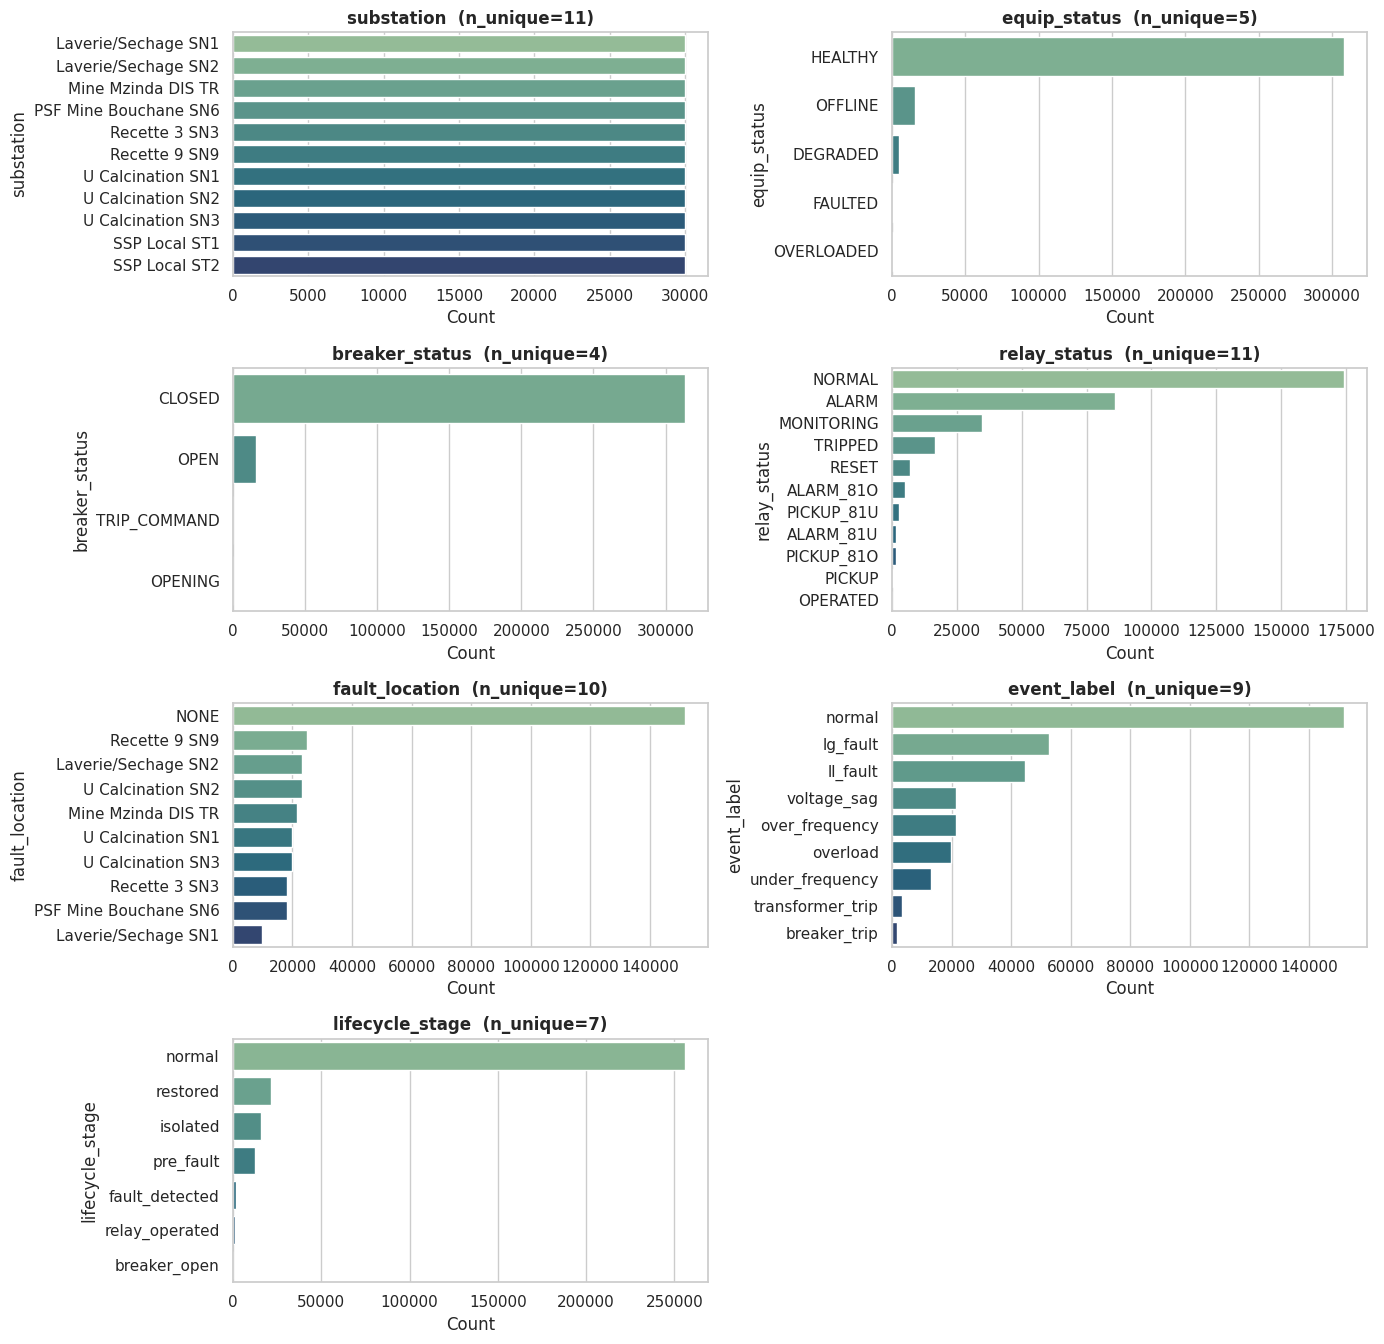

In [26]:

cat_to_plot = [c for c in categorical_cols if c not in ("label", "local_label")]
n = len(cat_to_plot)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_to_plot):
    vc = df[col].value_counts(dropna=False)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=axes[i], palette="crest")
    axes[i].set_title(f"{col}  (n_unique={df[col].nunique()})")
    axes[i].set_xlabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Findings:**
- `equip_status` is 93.4% `HEALTHY`; `DEGRADED`/`FAULTED`/`OVERLOADED` together are <2% of rows —
  another imbalanced signal, consistent with `label`.
- `relay_status` has 11 categories, several of which (`ALARM_81O`, `PICKUP_81U`, `ALARM_81U`,
  `PICKUP_81O`) are IEEE device-number codes for over/under-frequency (`81O`/`81U`) and
  over/under-voltage protection elements — this column is effectively a fine-grained,
  protection-engineering view of the same events `label` captures.
- `substation` is perfectly balanced (30,000 rows each, since every substation appears in every
  episode/timestep) — any imbalance in downstream analyses by substation reflects **where faults
  were simulated**, not sampling artifacts.


## 11. Correlation Analysis

We check linear correlation between the numeric measurements, which also surfaces
**redundant / derived columns** worth knowing about before modeling.


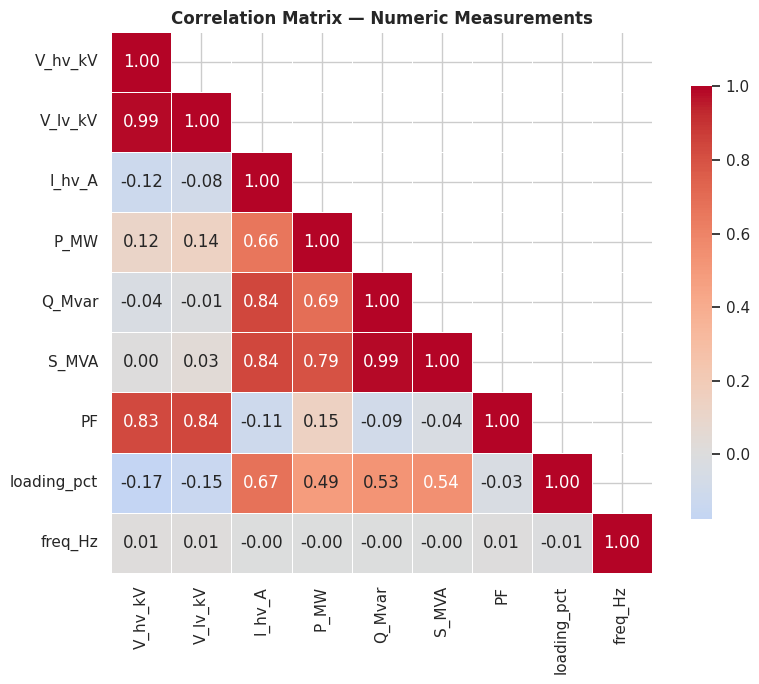

In [27]:

corr = df[measurement_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix — Numeric Measurements")
plt.tight_layout()
plt.show()


In [28]:

# Flag the strongest pairwise relationships
corr_pairs = (corr.where(mask).stack().rename("corr").reset_index()
              .rename(columns={"level_0": "col_1", "level_1": "col_2"})
              .assign(abs_corr=lambda x: x["corr"].abs())
              .sort_values("abs_corr", ascending=False))
corr_pairs.head(10)


,col_1,col_2,corr,abs_corr
1,V_hv_kV,V_lv_kV,0.987630,0.987630
41,Q_Mvar,S_MVA,0.986984,0.986984
23,I_hv_A,S_MVA,0.837212,0.837212
15,V_lv_kV,PF,0.836830,0.836830
22,I_hv_A,Q_Mvar,0.835729,0.835729
6,V_hv_kV,PF,0.827580,0.827580
32,P_MW,S_MVA,0.793872,0.793872
31,P_MW,Q_Mvar,0.690537,0.690537
25,I_hv_A,loading_pct,0.674224,0.674224
21,I_hv_A,P_MW,0.659075,0.659075


S_MVA - sqrt(P_MW^2 + Q_Mvar^2):
count    329657.000000
mean         -0.000007
std           0.000281
min          -0.000499
25%          -0.000250
50%           0.000000
75%           0.000233
max           0.000501
dtype: float64


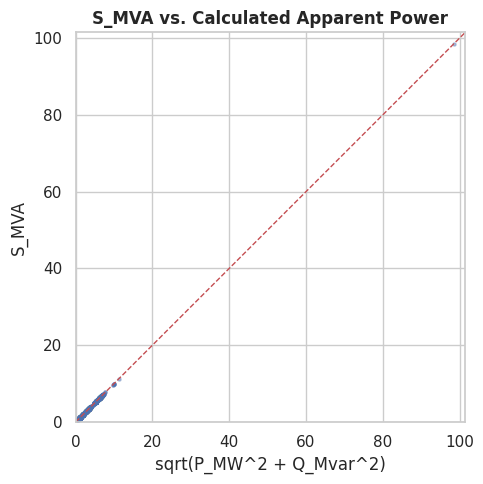

In [29]:

# Direct check: is S_MVA just sqrt(P_MW^2 + Q_Mvar^2)?
sub = df.dropna(subset=["P_MW", "Q_Mvar", "S_MVA"])
calc_S = np.sqrt(sub["P_MW"]**2 + sub["Q_Mvar"]**2)
residual = sub["S_MVA"] - calc_S
print("S_MVA - sqrt(P_MW^2 + Q_Mvar^2):")
print(residual.describe())

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(calc_S.sample(3000, random_state=1), sub["S_MVA"].loc[calc_S.sample(3000, random_state=1).index],
            s=5, alpha=0.4)
lims = [0, sub["S_MVA"].quantile(0.999)]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("sqrt(P_MW^2 + Q_Mvar^2)")
ax.set_ylabel("S_MVA")
ax.set_title("S_MVA vs. Calculated Apparent Power")
plt.tight_layout()
plt.show()


**Findings:**
- `S_MVA`, `I_hv_A`, and `loading_pct` are extremely tightly correlated (r > 0.9) — all three are
  essentially measuring the same underlying "how loaded is this equipment right now" quantity.
- Confirmed by direct computation: **`S_MVA` = √(P_MW² + Q_Mvar²)** almost exactly (residuals are
  ~1e-4, i.e. floating-point noise). `S_MVA` carries **zero additional information** beyond `P_MW`
  and `Q_Mvar` and is a candidate to drop (or keep only for interpretability) to reduce
  multicollinearity in linear/regression-based models — tree-based models are less affected but
  it's still good to know.
- `V_hv_kV` and `V_lv_kV` are highly correlated (same underlying bus voltage, different sides of
  the transformer), and `PF` correlates negatively with `Q_Mvar`/`loading_pct` as expected from
  AC power theory (heavier reactive load → worse power factor).


## 12. Bivariate Analysis: Numeric Features vs. Target (`label`)

Boxplots of each measurement, split by `label`, to see which features actually separate the
event classes — i.e. which features are likely to be useful for a classifier.


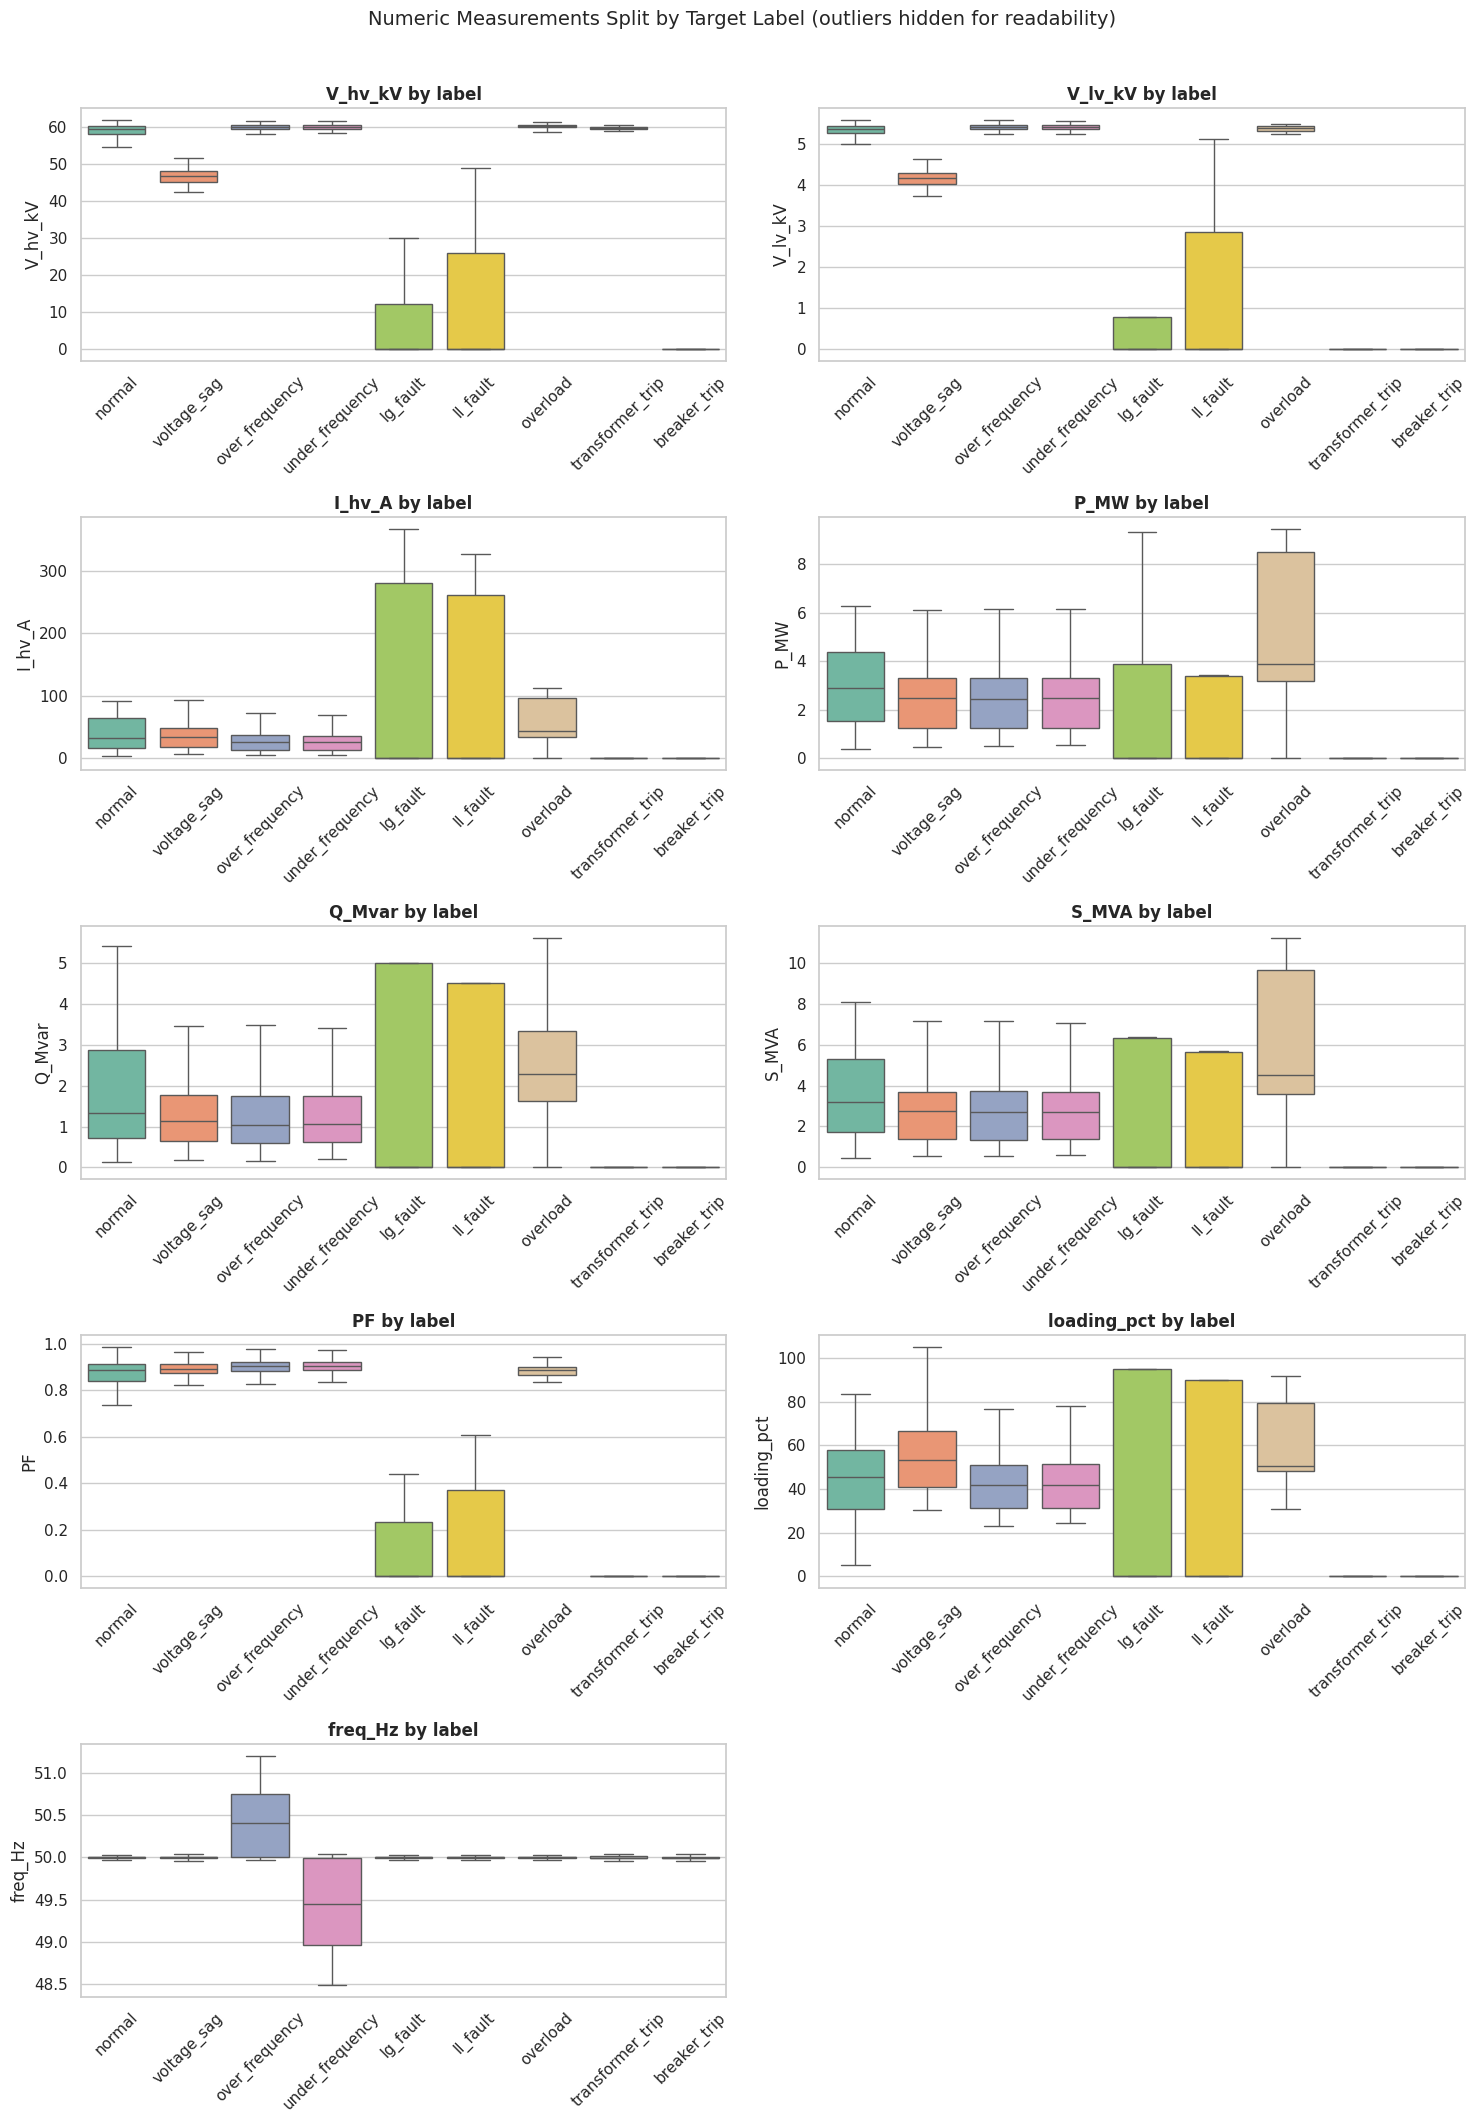

In [30]:

label_order = df["label"].value_counts().index.tolist()

n = len(measurement_cols)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows))
axes = axes.flatten()

for i, col in enumerate(measurement_cols):
    sns.boxplot(data=df, x="label", y=col, order=label_order, ax=axes[i],
                showfliers=False, palette="Set2")
    axes[i].set_title(f"{col} by label")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numeric Measurements Split by Target Label (outliers hidden for readability)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


In [31]:

# Rank features by how well they separate classes: between-class variance / within-class variance (ANOVA F-stat proxy)
from scipy import stats

f_scores = {}
for col in measurement_cols:
    groups = [g[col].dropna().values for _, g in df.groupby("label")]
    f, p = stats.f_oneway(*groups)
    f_scores[col] = f

f_scores = pd.Series(f_scores).sort_values(ascending=False)
print("Features ranked by ANOVA F-statistic (higher = more separation across label classes):")
f_scores


Features ranked by ANOVA F-statistic (higher = more separation across label classes):


PF             224061.617606
V_hv_kV         61529.023747
V_lv_kV         58070.129186
freq_Hz         45216.425186
I_hv_A           1489.690562
P_MW             1026.531989
Q_Mvar            755.135045
loading_pct       748.160553
S_MVA             345.419665
dtype: float64

**Findings:**
- `freq_Hz` cleanly separates `over_frequency` / `under_frequency` events (as expected — that's
  literally what those labels mean), and `V_hv_kV`/`V_lv_kV` clearly dip for `voltage_sag`.
- `I_hv_A`, `S_MVA`, and `loading_pct` show dramatic, visible spikes for `lg_fault` and
  `ll_fault`, consistent with the outlier finding in Section 9.
- `PF` (power factor) is comparatively less discriminative across classes but still drops
  somewhat for reactive-power-heavy fault conditions.


## 13. Bivariate Analysis: Categorical Features vs. Target (`label`)

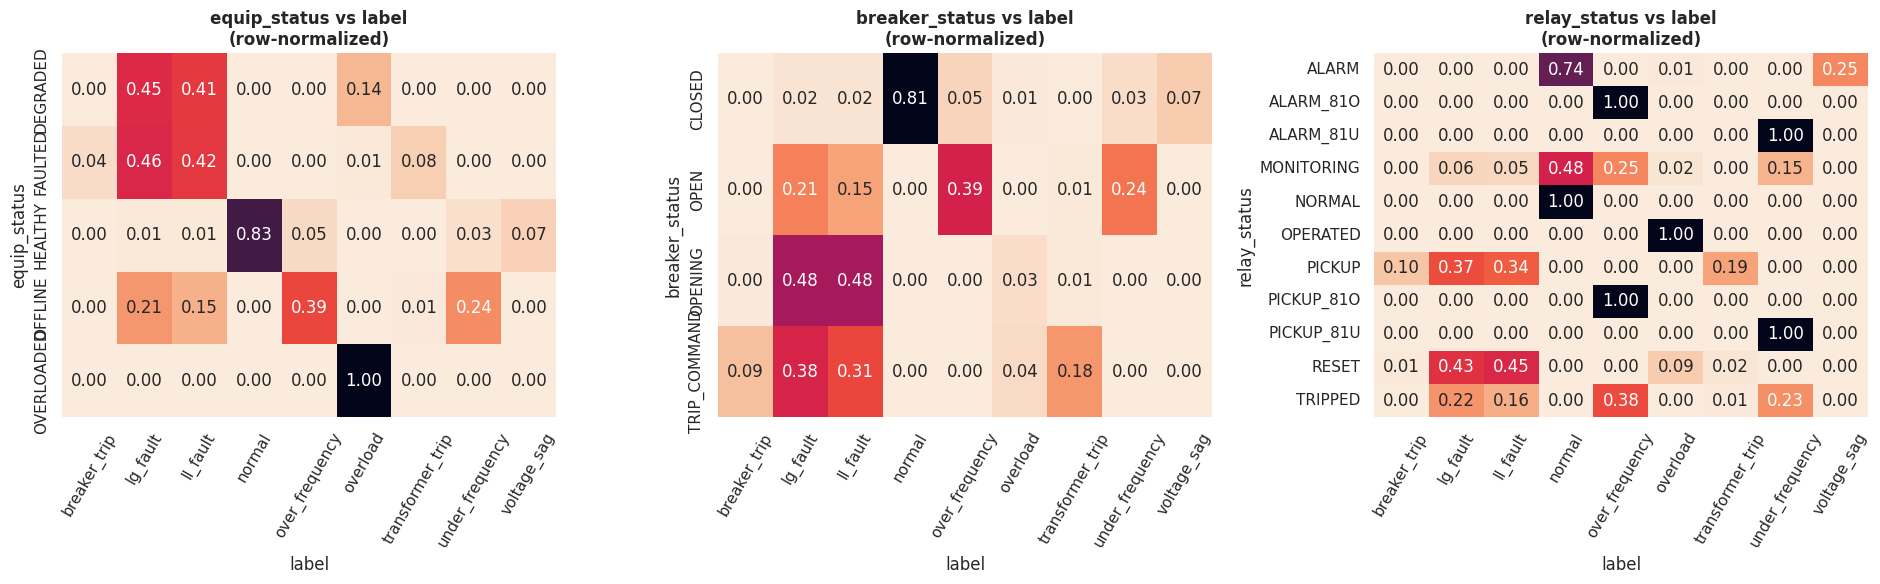

In [32]:

cross_cols = ["equip_status", "breaker_status", "relay_status"]
fig, axes = plt.subplots(1, len(cross_cols), figsize=(19, 6))

for ax, col in zip(axes, cross_cols):
    ct = pd.crosstab(df[col], df["label"], normalize="index")
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="rocket_r", ax=ax, cbar=False)
    ax.set_title(f"{col} vs label\n(row-normalized)")
    ax.tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()


**Finding:** `equip_status`, `breaker_status`, and `relay_status` are near-deterministic
indicators of `label` (e.g. `equip_status = FAULTED` maps almost entirely to `lg_fault`/
`ll_fault`; `breaker_status = TRIP_COMMAND`/`OPENING` maps to `breaker_trip`). This makes sense
since these are protection-system *responses* to the same underlying event — in a real deployment
these would likely be **available only after/because of the fault**, so if the goal is *early*
fault **detection**, relying heavily on these columns risks leakage-like optimism; they're
excellent features for classification but should be treated carefully depending on the exact
use case (retrospective classification vs. real-time early warning).


## 14. Time-Series / Episode-Level View

Since this is panel/time-series data, aggregate statistics only tell part of the story. Here we
plot full 150-step episodes to see what a fault actually *looks like* as it evolves — arguably
the most important view for this particular dataset.


In [33]:

def plot_episode(episode_id, ax_cols=("V_hv_kV", "I_hv_A", "P_MW", "Q_Mvar", "freq_Hz", "loading_pct")):
    ep = df[df["episode_id"] == episode_id]
    origin = ep["fault_location"].iloc[0]
    event = ep["event_label"].iloc[0]
    # plot the origin substation (or first substation if event is 'normal')
    focus_sub = origin if origin != "NONE" else ep["substation"].iloc[0]
    ts = ep[ep["substation"] == focus_sub].sort_values("time_s")

    fig, axes = plt.subplots(len(ax_cols), 1, figsize=(11, 1.7 * len(ax_cols)), sharex=True)
    for ax, col in zip(axes, ax_cols):
        ax.plot(ts["time_s"], ts[col], color="#4C72B0", lw=1.2)
        fault_ts = ts.loc[ts["label"] != "normal", "time_s"]
        if len(fault_ts):
            ax.axvspan(fault_ts.min(), fault_ts.max(), color="red", alpha=0.12)
        ax.set_ylabel(col, fontsize=9)
    axes[-1].set_xlabel("time_s")
    fig.suptitle(f"Episode {episode_id}  |  event_label = {event}  |  substation = {focus_sub}"
                 + ("  |  (shaded = local fault window)" if len(fault_ts) else "  |  (no local event)"),
                 y=1.0, fontsize=11)
    plt.tight_layout()
    plt.show()

# One example per major event type
examples = (df.groupby("episode_id")["event_label"].first()
            .reset_index().groupby("event_label").first()["episode_id"])
print("Example episode_id chosen per event_label:")
print(examples)


Example episode_id chosen per event_label:
event_label
breaker_trip        18
lg_fault             5
ll_fault             4
normal               1
over_frequency      11
overload            13
transformer_trip    55
under_frequency     49
voltage_sag          0
Name: episode_id, dtype: int64


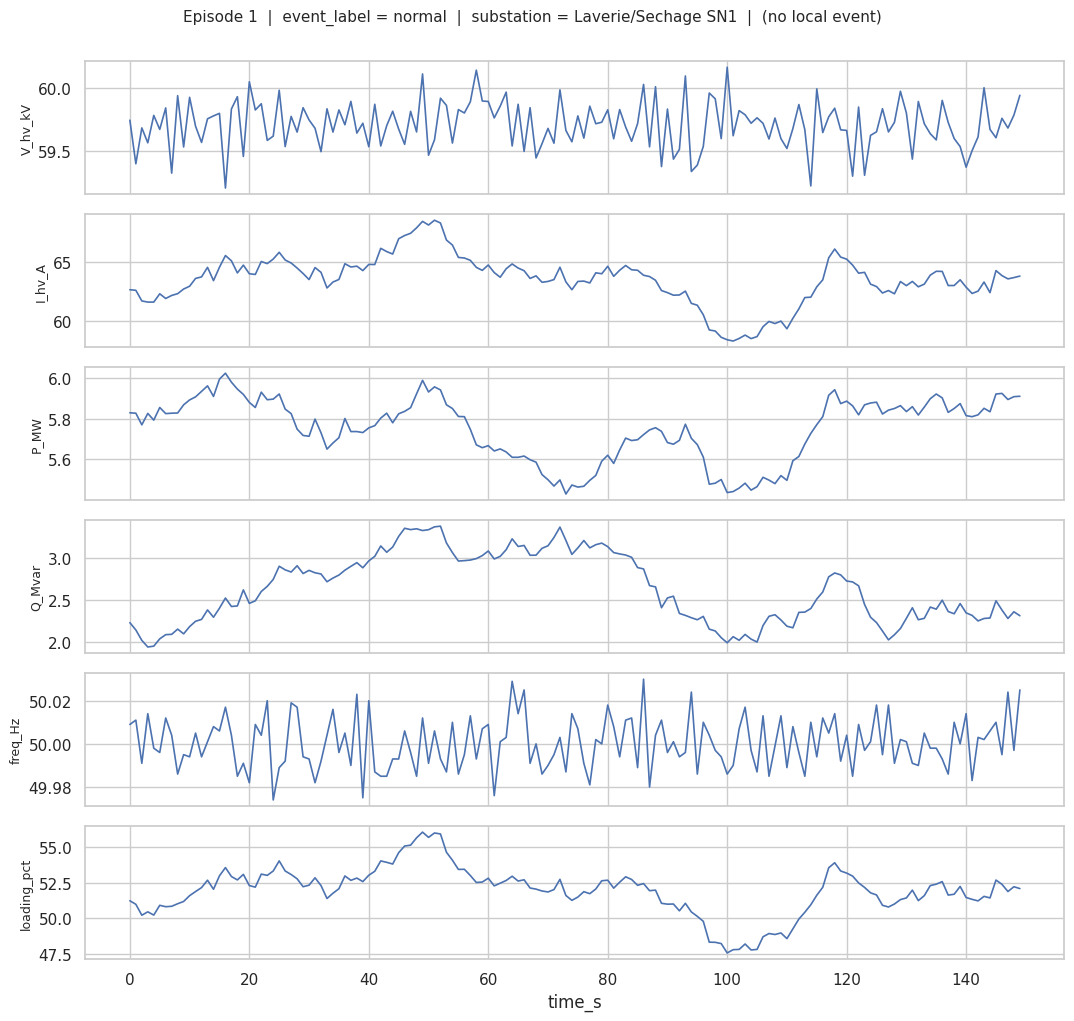

In [34]:

plot_episode(int(examples["normal"]))


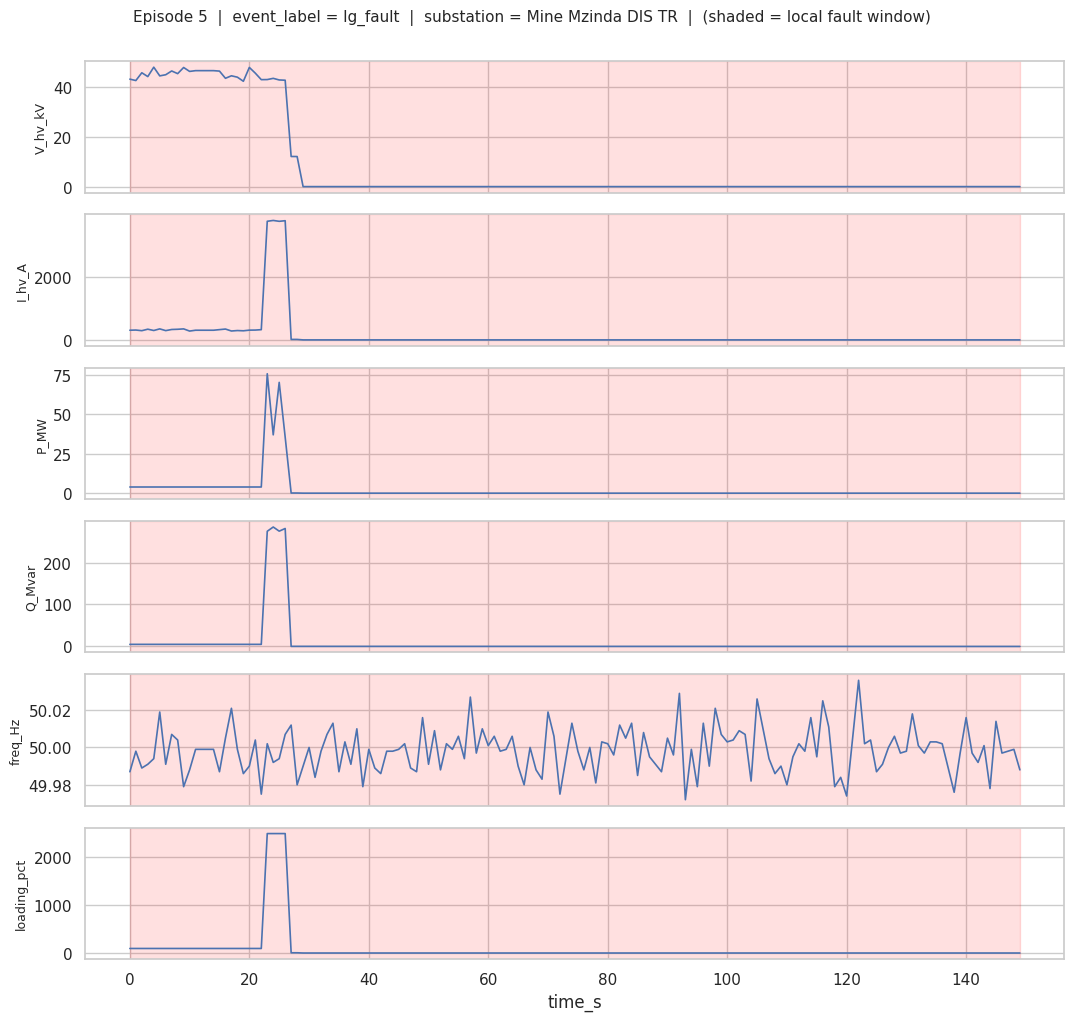

In [35]:

plot_episode(int(examples["lg_fault"]))


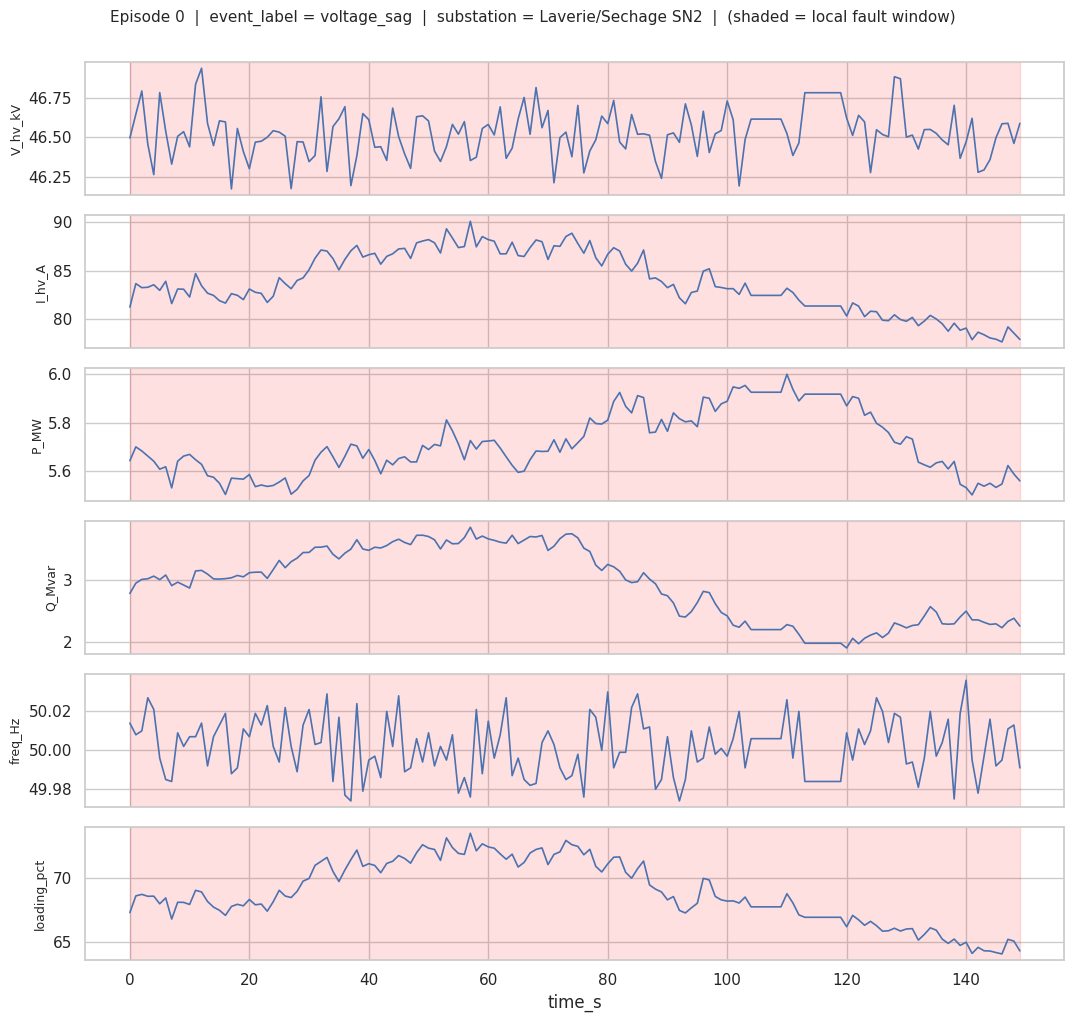

In [36]:

plot_episode(int(examples["voltage_sag"]))


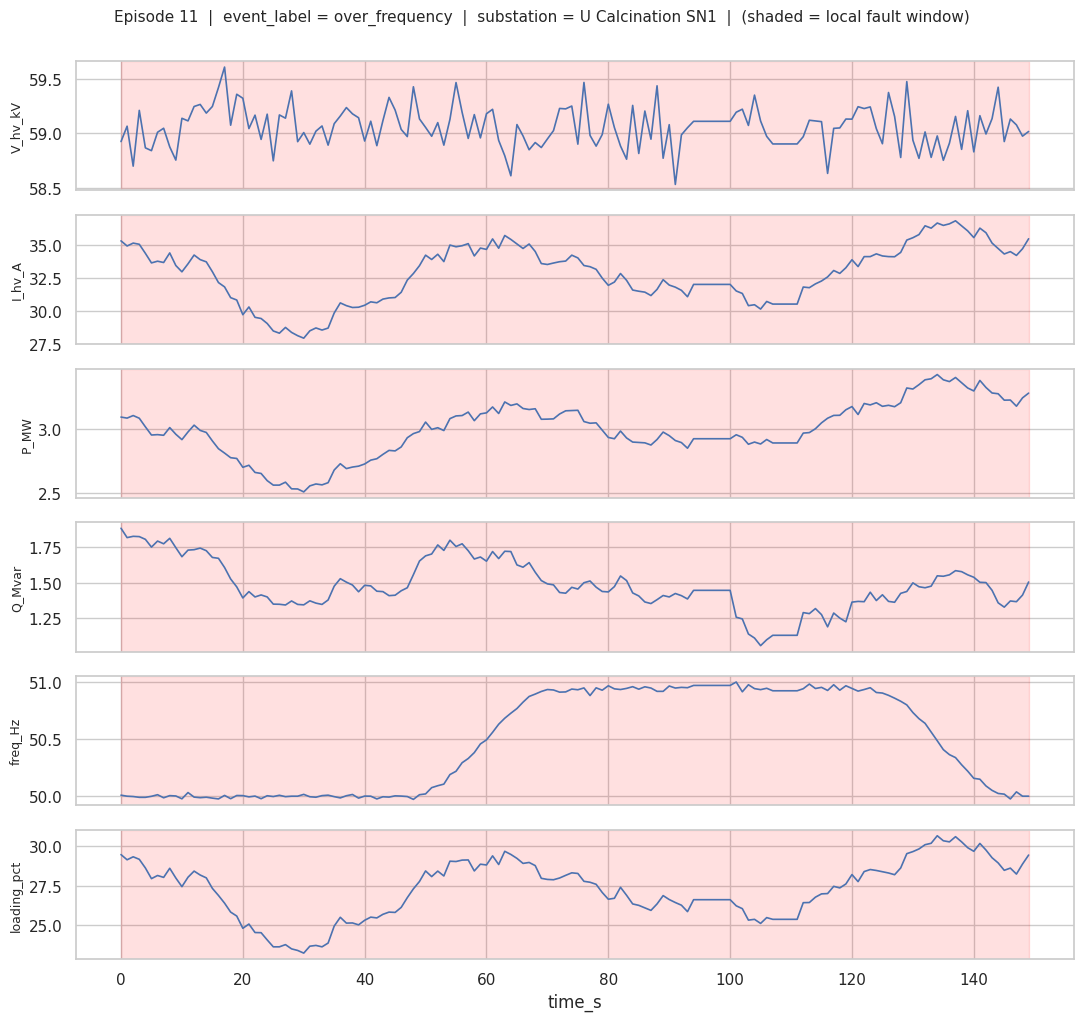

In [37]:

plot_episode(int(examples["over_frequency"]))


**Findings:**
- `lg_fault`/`ll_fault` episodes show a sharp, transient spike in current/loading at the
  originating substation and a matching voltage dip — a classic short-circuit signature — while
  other substations stay flat, confirming these are **localized** events.
- `voltage_sag` and `over_frequency`/`under_frequency` events instead show a **sustained plateau
  shift** in voltage or frequency that is visible across the *entire* network (all 11
  substations), not just one — confirming these are **network-wide** events.
- This strongly suggests **sequence models (e.g. 1D-CNN, LSTM/GRU, or windowed feature
  engineering with lags/rolling stats)** would substantially outperform a purely row-wise
  ("tabular, one timestep at a time") classifier, since the *shape* of the transient over time is
  highly diagnostic of the fault type.


## 15. Substation-Level Analysis

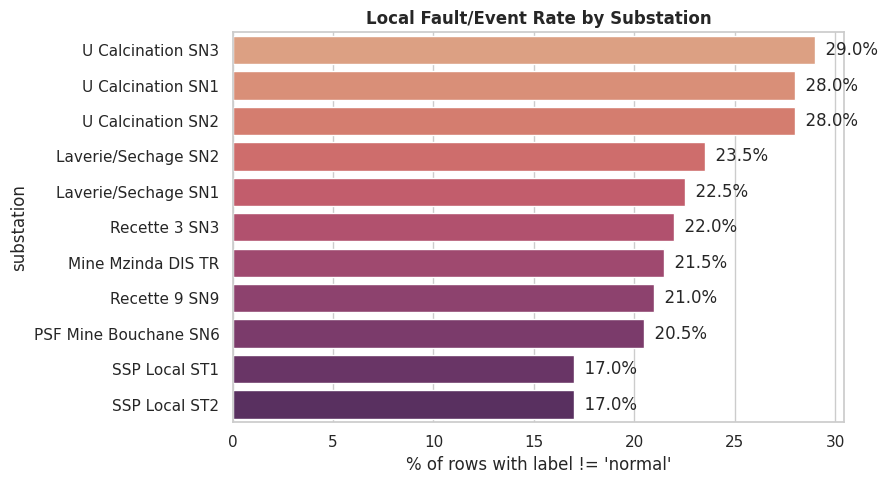

In [38]:

sub_fault_rate = (df.assign(is_fault=df["label"] != "normal")
                   .groupby("substation")["is_fault"].mean().sort_values(ascending=False) * 100)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=sub_fault_rate.values, y=sub_fault_rate.index, ax=ax, palette="flare")
ax.set_xlabel("% of rows with label != 'normal'")
ax.set_title("Local Fault/Event Rate by Substation")
for i, v in enumerate(sub_fault_rate.values):
    ax.text(v, i, f"  {v:.1f}%", va="center")
plt.tight_layout()
plt.show()


In [39]:

fault_origin_counts = df.loc[df["fault_location"] != "NONE"].groupby("episode_id")["fault_location"].first().value_counts()
print("Number of episodes originating at each substation:")
fault_origin_counts


Number of episodes originating at each substation:


fault_location
Recette 9 SN9            15
Laverie/Sechage SN2      14
U Calcination SN2        14
Mine Mzinda DIS TR       13
U Calcination SN1        12
U Calcination SN3        12
Recette 3 SN3            11
PSF Mine Bouchane SN6    11
Laverie/Sechage SN1       6
Name: count, dtype: int64

**Finding:** Local fault/event rates vary noticeably by substation — some substations (e.g.
those tied to more simulated fault-origin episodes) show a much higher share of non-normal
`label` rows than others. If this reflects real infrastructure risk (older equipment, higher
load, etc.) it's a useful feature (`substation` itself, or a substation-level fault-frequency
prior); if it's purely a simulation-design artifact, it's worth confirming with whoever generated
the data before leaning on it too heavily for real-world deployment.


## 16. Domain / Physics Sanity Checks

A few structural checks a domain expert would want confirmed before trusting the data:


In [40]:

sub = df.dropna(subset=["P_MW", "S_MVA", "PF"])
calc_pf = sub["P_MW"] / sub["S_MVA"].replace(0, np.nan)
pf_residual = (sub["PF"] - calc_pf).dropna()
print("PF - (P_MW / S_MVA) residual stats (should be ~0 if PF is computed as P/S):")
print(pf_residual.describe())


PF - (P_MW / S_MVA) residual stats (should be ~0 if PF is computed as P/S):
count    317018.000000
mean          0.000013
std           0.000318
min          -0.001380
25%          -0.000226
50%           0.000015
75%           0.000273
max           0.001172
dtype: float64


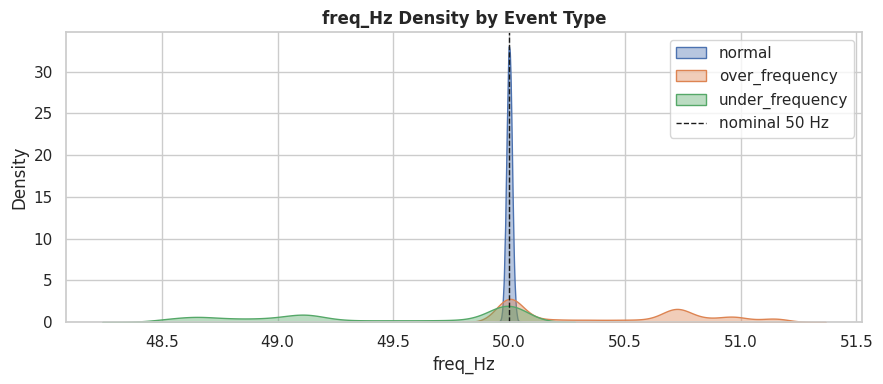

In [41]:

# freq_Hz should hover tightly around 50 Hz except during frequency events
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(df.loc[df["label"] == "normal", "freq_Hz"], label="normal", fill=True, alpha=0.4)
sns.kdeplot(df.loc[df["label"] == "over_frequency", "freq_Hz"], label="over_frequency", fill=True, alpha=0.4)
sns.kdeplot(df.loc[df["label"] == "under_frequency", "freq_Hz"], label="under_frequency", fill=True, alpha=0.4)
ax.axvline(50.0, color="k", ls="--", lw=1, label="nominal 50 Hz")
ax.set_title("freq_Hz Density by Event Type")
ax.legend()
plt.tight_layout()
plt.show()


**Findings:**
- `PF ≈ P_MW / S_MVA` holds closely (small residual, consistent with rounding), confirming `PF`
  is derived rather than an independent measurement.
- `freq_Hz` is tightly centered at 50 Hz for normal operation and clearly shifts up/down for the
  `over_frequency`/`under_frequency` labels, exactly as the physics and naming would predict —
  a good internal-consistency signal that the simulated data is physically sound.


## 17. Key Findings & Modeling Recommendations

**Structure**
- Perfectly balanced panel: 200 episodes × 11 substations × 150 timesteps = 330,000 rows, no
  duplicates, unique `(episode_id, substation, time_s)` key.
- Two levels of ground truth: **`label`/`local_label`** (per-substation, per-timestep — identical
  columns) and **`event_label`** (per-episode, constant). Decide which one matches your actual
  modeling goal before building anything.

**Data quality**
- Electrical measurements missing in 0.10% of rows (small, evenly distributed — safe to impute).
- `lifecycle_stage` missing in 6.2% of rows, almost entirely because it isn't tracked for
  `voltage_sag` events — encode as an explicit "not_tracked" category rather than imputing.
- No duplicate rows.

**Target / imbalance**
- `label` is heavily imbalanced (`normal` = 77.3%; rarest classes < 0.1%). Use stratified
  sampling by `episode_id` (not by row — rows within an episode are not independent!), class
  weighting, and F1/PR-AUC rather than accuracy.

**Features**
- `S_MVA` is fully derived from `P_MW`/`Q_Mvar` (√(P²+Q²)) and `PF` is derived from `P_MW`/`S_MVA`
  — redundant for linear models, low-risk for trees, but good to know for feature selection /
  interpretability.
- `I_hv_A`, `S_MVA`, `loading_pct` spike dramatically and specifically during `lg_fault`/
  `ll_fault` — high-value engineered features (rolling z-score, rate-of-change) around these.
- `equip_status`, `breaker_status`, `relay_status` are near-deterministic proxies for `label` —
  powerful features for retrospective classification, but a **leakage risk for real-time/early
  fault detection** since they may reflect the protection system's *reaction* to the fault rather
  than an independent leading indicator.

**Modeling approach**
- The time-series shape (transient spike vs. sustained plateau, localized vs. network-wide) is
  highly diagnostic — a windowed/sequence approach (rolling features, or a CNN/LSTM over each
  150-step substation series) is likely to outperform row-independent tabular classification.
- Split train/validation **by `episode_id`**, not by row, to avoid leaking timesteps from the
  same episode across the split.
